<a href="https://colab.research.google.com/github/FrankArcosAnselmo/mI_lab01_Fa/blob/develop/LAB13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

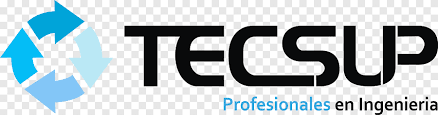
### LABORATORIO 13
### NOMBRE: ARCOS ANSELMO, FRANK FERNANDO

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats

### A) Realice el preprocesamiento de la información que incluya el análisis de datos faltantes y tratamiento de outliers a nivel univariado y multivariado. Además convierta las variablescategóricas a dummies y aplique un escalamiento a las variables numéricas

In [2]:
import pandas as pd

# Ruta del archivo en tu Drive
file_path = '/content/drive/MyDrive/BIG DATA Y CIENCIAS DE DATOS/MINERIA DE DATOS/employees.xlsx'

# Leer el archivo
df = pd.read_excel(file_path)

# Mostrar las primeras filas
df.head()


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,2015-01-01 00:00:00,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,2015-01-01 00:00:00,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,2015-01-01 00:00:00,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,2015-01-01 00:00:00,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,2015-01-01 00:00:00,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [3]:
# Eliminar 'date'
if 'date' in df.columns:
    df.drop(columns='date', inplace=True)


In [4]:
# Clasificar productividad
df['actual_productivity'] = (df['actual_productivity'] >= 0.5).astype(int)

In [5]:
# Identificar columnas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('actual_productivity')
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [8]:
# Outliers univariados (IQR)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

In [9]:
# Outliers multivariados (z-score > 3)
z_scores = np.abs(stats.zscore(df[num_cols]))
df = df[(z_scores < 3).all(axis=1)]


In [10]:
# Dummies
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [11]:
# Outliers multivariados (z-score > 3) pero con filtro menos agresivo
z_scores = np.abs(stats.zscore(df[num_cols]))
mask = (z_scores < 3).all(axis=1)

# Avisa cuántos se van a eliminar
print(f"Filas originales: {df.shape[0]}")
print(f"Filas eliminadas por z-score: {(~mask).sum()}")
df = df[mask]


Filas originales: 0
Filas eliminadas por z-score: 0


  ### B) Separe los datos en entrenamiento (80%) y prueba (20%) y entrene los modelos k-NN, SVM, regresión logística, árbol de clasificación, Random Forest y Naive Bayes definiendo distintos hiperparámetros para cada modelo

In [16]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/BIG DATA Y CIENCIAS DE DATOS/MINERIA DE DATOS/employees.xlsx')

# Eliminar columna 'date'
df.drop(columns='date', inplace=True)

# Redefinir la variable objetivo
df['actual_productivity'] = df['actual_productivity'].apply(lambda x: 1 if x >= 0.5 else 0)

# Eliminar filas con valores faltantes
df.dropna(inplace=True)

# Revisar que no esté vacío
print(f"Filas luego del preprocesamiento: {df.shape[0]}")





Filas luego del preprocesamiento: 691


In [17]:
# Convertir variables categóricas a dummies
df = pd.get_dummies(df, drop_first=True)

# Separar X e y
X = df.drop('actual_productivity', axis=1)
y = df['actual_productivity']

print(f"Número de muestras: {X.shape[0]}")


Número de muestras: 691


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Modelos y sus hiperparámetros básicos
models = {
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale'),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5),
    "Naive Bayes": GaussianNB()
}

# Entrenar y evaluar
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


k-NN Accuracy: 0.9065
SVM Accuracy: 0.9065
Logistic Regression Accuracy: 0.9353
Decision Tree Accuracy: 0.8993
Random Forest Accuracy: 0.9065
Naive Bayes Accuracy: 0.9209


### C) Utilice hiperparámetros estándar, la búsqueda en cuadrícula y búsqueda aleatoria para poder encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy junto con los hiperparámetros óptimos para dicho modelo

In [20]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Ejemplo con Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Mejor Accuracy (GridSearch - Random Forest):", grid.best_score_)
print("Mejores parámetros:", grid.best_params_)


Mejor Accuracy (GridSearch - Random Forest): 0.9202784602784604
Mejores parámetros: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}


In [21]:
from scipy.stats import uniform

param_dist = {
    'C': uniform(0.1, 10),
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

rand_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)
rand_search.fit(X_train, y_train)

print("Mejor Accuracy (RandomSearch - SVM):", rand_search.best_score_)
print("Mejores parámetros:", rand_search.best_params_)


Mejor Accuracy (RandomSearch - SVM): 0.913054873054873
Mejores parámetros: {'C': np.float64(7.41993941811405), 'gamma': 'scale', 'kernel': 'linear'}


In [22]:
best_model_name = max(results, key=results.get)
print("Modelo con mejor accuracy (hiperparámetros por defecto):", best_model_name, "con", results[best_model_name])


Modelo con mejor accuracy (hiperparámetros por defecto): Logistic Regression con 0.935251798561151
